# Tester les requetes et dataframe utilisés dans le Dashboard

In [1]:
%matplotlib notebook
%matplotlib inline

In [2]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data (en local)

In [45]:
data_path = 'c:/users/innov/python_venv/oc-pj7/input'
data = pd.read_csv(f'{data_path}/application_train_20250103_pred.csv')
#data = data.iloc[:, 3:]  # Je supprime des colonnes de réplication des index (je ne sais pas d'où elles viennent mais pas grave)
data.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 307510 entries, 0 to 307509
Data columns (total 151 columns):
 #    Column                               Non-Null Count   Dtype  
---   ------                               --------------   -----  
 0    SK_ID_CURR                           307510 non-null  int64  
 1    TARGET                               307510 non-null  float64
 2    FLAG_OWN_CAR                         307510 non-null  object 
 3    FLAG_OWN_REALTY                      307510 non-null  int64  
 4    CNT_CHILDREN                         307510 non-null  int64  
 5    AMT_INCOME_TOTAL                     307510 non-null  float64
 6    AMT_CREDIT                           307510 non-null  float64
 7    AMT_ANNUITY                          307498 non-null  float64
 8    AMT_GOODS_PRICE                      307510 non-null  float64
 9    NAME_TYPE_SUITE                      306218 non-null  object 
 10   NAME_INCOME_TYPE                     307510 non-null  object 
 11   NAM

In [39]:
client_base =  pd.read_csv(f'{data_path}/application_test_20250103.csv')
client_base = client_base.iloc[:, 3:]  # Je supprime des colonnes de réplication des index (je ne sais pas d'où elles viennent mais pas grave)
client_base.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 150 columns):
 #    Column                               Non-Null Count  Dtype  
---   ------                               --------------  -----  
 0    SK_ID_CURR                           48744 non-null  int64  
 1    TARGET                               0 non-null      float64
 2    FLAG_OWN_CAR                         48744 non-null  object 
 3    FLAG_OWN_REALTY                      48744 non-null  int64  
 4    CNT_CHILDREN                         48744 non-null  int64  
 5    AMT_INCOME_TOTAL                     48744 non-null  float64
 6    AMT_CREDIT                           48744 non-null  float64
 7    AMT_ANNUITY                          48720 non-null  float64
 8    AMT_GOODS_PRICE                      48744 non-null  float64
 9    NAME_TYPE_SUITE                      47833 non-null  object 
 10   NAME_INCOME_TYPE                     48744 non-null  object 
 11   NAME_EDUCATIO

In [5]:
client_base.head()

,SK_ID_CURR,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,AMT_ALL_SUM_DEBT,AMT_ALL_SUM_OVERDUE,AMT_ALL_MAX_OVERDUE,CODE_GENDER_F,CODE_GENDER_M,CODE_GENDER_XNA,AMT_ALL_SUM_MEAN,RATIO_ALL_SUM_OVERDUE_TO_INCOME,RATIO_ALL_MAX_OVERDUE_TO_INCOME,RATIO_ALL_SUM_DEBT_TO_INCOME
0,100001,NaN,N,1,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,...,595173.600,0.000,0.000,1,0,0,184644.000000,0.000000,0.000000,4.408693
1,100005,NaN,N,1,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,...,557213.355,0.000,4813.200,0,1,0,174319.875000,0.000000,0.583418,5.628418
2,100013,NaN,Y,1,0,202500.0,663264.0,69777.0,630000.0,NaN,...,-373892.625,171562.725,23153.985,0,1,0,379545.222857,0.847223,1.372088,-1.846383
3,100028,NaN,N,1,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,...,218010.465,70348.230,11250.000,1,0,0,129077.472000,0.223328,0.428571,0.692097
4,100038,NaN,Y,0,1,180000.0,625500.0,32067.0,625500.0,Unaccompanied,...,-29497.950,0.000,0.000,0,1,0,92605.500000,0.000000,0.000000,-0.163878


In [42]:
domain_features=['DAYS_BIRTH', 'CODE_GENDER_F', 'FLAG_RISKED_ORGANIZATION_TYPE', 
                 'RATIO_INCOME_TO_FAM_MEMBERS', 'FLAG_STABLE_INCOME_TYPE',
                 'EXT_SOURCE_2',
                 'AMT_ALL_SUM_MEAN', 'RATIO_ALL_SUM_DEBT_TO_INCOME', 'RATIO_ALL_SUM_OVERDUE_TO_INCOME', 'RATIO_ALL_MAX_OVERDUE_TO_INCOME']

In [73]:
id_client = 100028
client_data = client_base.loc[client_base['SK_ID_CURR'] == id_client, domain_features].stack()
client_data

3  DAYS_BIRTH                         -13976.000000
   CODE_GENDER_F                           1.000000
   FLAG_RISKED_ORGANIZATION_TYPE           0.000000
   RATIO_INCOME_TO_FAM_MEMBERS         78750.000000
   FLAG_STABLE_INCOME_TYPE                 0.000000
   EXT_SOURCE_2                            0.509677
   AMT_ALL_SUM_MEAN                   129077.472000
   RATIO_ALL_SUM_DEBT_TO_INCOME            0.692097
   RATIO_ALL_SUM_OVERDUE_TO_INCOME         0.223328
   RATIO_ALL_MAX_OVERDUE_TO_INCOME         0.428571
dtype: float64

# Data depuis Google Storage

In [16]:
import google.auth
from google.cloud import storage

In [17]:
credentials, project = google.auth.default()
print(f"Credentials : {credentials}") # Affiche les identifiants utilisés (devrait être None)
print(f"Project : {project}") # Affiche le projet (devrait être None ou détecté automatiquement)
# storage_client = storage.Client(credentials=None)

DefaultCredentialsError: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information.

In [ ]:
bucket = storage_client.bucket(bucket_name)

In [10]:
def telecharger_fichier(nom_fichier_source, nom_fichier_destination):
    """Télécharge un fichier depuis Cloud Storage."""
    bucket_name = 'bkjhd-sjhgsd-sq-iuoiu-iu-h-kjhkjh-jh'  # A renseigner
    storage_client = storage.Client(credentials=None)
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(nom_fichier_source)
    blob.download_to_filename(nom_fichier_destination)
    print(f"Fichier {nom_fichier_source} téléchargé depuis {bucket_name} vers {nom_fichier_destination}.")
    return

In [12]:
telecharger_fichier('/input/application_test.csv', '/tmp/test.csv')

DefaultCredentialsError: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information.

## Essais lecture data depuismon Google Drive

In [57]:
URL_data = 'https://drive.google.com/uc?id=1-bsOZer49Cz0g1xNK1ygk657k94Jilu3'  # URL Public
URL_client = 'https://drive.google.com/uc?id=1-ZX9AKIhO6rFqbcd3sOqdp3rPtZkD4QA'
URL_data = 'https://drive.google.com/uc?id=1-bsOZer49Cz0g1xNK1ygk657k94Jilu3'
try:
    data = pd.read_csv(URL_data, nrows=1000)
    data = data.iloc[:, 3:]  # Je supprime des colonnes de réplication des index (je ne sais pas d'où elles viennent mais pas grave)
    data.info(verbose=True, show_counts=True)
except pd.errors.ParserError as e:
    print(f"Erreur lors de la lecture du CSV : {e}")
except Exception as e:
    print(f"Une erreur s'est produite : {e}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame


In [51]:
URL_data = 'https://drive.google.com/file/d/1-bsOZer49Cz0g1xNK1ygk657k94Jilu3'  # URL Public
URL_client = 'G:/My Drive/DataScience/OpenClassroom/public/oc-pj7/data/application_test_features.csv'
URL_client = 'https://drive.google.com/file/d/1-ZX9AKIhO6rFqbcd3sOqdp3rPtZkD4QA/view?export=download'  # URL Public
URL_client = 'https://drive.google.com/file/d/1-ZX9AKIhO6rFqbcd3sOqdp3rPtZkD4QA/view?export=download'  # URL Public
URL_data = 'https://drive.google.com/uc?id=1-bsOZer49Cz0g1xNK1ygk657k94Jilu3'  # URL Public
URL_client = 'https://drive.google.com/uc?id=1-ZX9AKIhO6rFqbcd3sOqdp3rPtZkD4QA'
try:
    data = pd.read_csv(URL_client)
    data = data.iloc[:, 3:]  # Je supprime des colonnes de réplication des index (je ne sais pas d'où elles viennent mais pas grave)
    data.info(verbose=True, show_counts=True)
except pd.errors.ParserError as e:
    print(f"Erreur lors de la lecture du CSV : {e}")
except Exception as e:
    print(f"Une erreur s'est produite : {e}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 150 columns):
 #    Column                               Non-Null Count  Dtype  
---   ------                               --------------  -----  
 0    SK_ID_CURR                           48744 non-null  int64  
 1    TARGET                               0 non-null      float64
 2    FLAG_OWN_CAR                         48744 non-null  object 
 3    FLAG_OWN_REALTY                      48744 non-null  int64  
 4    CNT_CHILDREN                         48744 non-null  int64  
 5    AMT_INCOME_TOTAL                     48744 non-null  float64
 6    AMT_CREDIT                           48744 non-null  float64
 7    AMT_ANNUITY                          48720 non-null  float64
 8    AMT_GOODS_PRICE                      48744 non-null  float64
 9    NAME_TYPE_SUITE                      47833 non-null  object 
 10   NAME_INCOME_TYPE                     48744 non-null  object 
 11   NAME_EDUCATIO

In [30]:
data.head()

,SK_ID_CURR,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,AMT_ALL_SUM_DEBT,AMT_ALL_SUM_OVERDUE,AMT_ALL_MAX_OVERDUE,CODE_GENDER_F,CODE_GENDER_M,CODE_GENDER_XNA,AMT_ALL_SUM_MEAN,RATIO_ALL_SUM_OVERDUE_TO_INCOME,RATIO_ALL_MAX_OVERDUE_TO_INCOME,RATIO_ALL_SUM_DEBT_TO_INCOME
0,100001,NaN,N,1,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,...,595173.600,0.000,0.000,1,0,0,184644.000000,0.000000,0.000000,4.408693
1,100005,NaN,N,1,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,...,557213.355,0.000,4813.200,0,1,0,174319.875000,0.000000,0.583418,5.628418
2,100013,NaN,Y,1,0,202500.0,663264.0,69777.0,630000.0,NaN,...,-373892.625,171562.725,23153.985,0,1,0,379545.222857,0.847223,1.372088,-1.846383
3,100028,NaN,N,1,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,...,218010.465,70348.230,11250.000,1,0,0,129077.472000,0.223328,0.428571,0.692097
4,100038,NaN,Y,0,1,180000.0,625500.0,32067.0,625500.0,Unaccompanied,...,-29497.950,0.000,0.000,0,1,0,92605.500000,0.000000,0.000000,-0.163878


In [34]:
data.sample(1).to_numpy()

array([[335944, nan, 'Y', 1, 1, 81000.0, 312840.0, 22761.0, 247500.0,
        'Family', 'Commercial associate',
        'Secondary / secondary special', 'Married', 'House / apartment',
        0.006296, -11336, -1894.0, -103.0, -1382, 16.0, 1, 1, 0, 1, 0, 0,
        'Core staff', 3.0, 3, 3, 'MONDAY', 11, 0, 0, 0, 0, 1, 1,
        'Trade: type 7', 0.549511457430798, 0.3568402042054893,
        0.3672910183026313, 0.0928, nan, 0.9891, nan, nan, nan, 0.2069,
        0.1667, nan, nan, nan, nan, nan, nan, 0.0945, nan, 0.9891, nan,
        nan, nan, 0.2069, 0.1667, nan, nan, nan, nan, nan, nan, 0.0937,
        nan, 0.9891, nan, nan, nan, 0.2069, 0.1667, nan, nan, nan, nan,
        nan, nan, nan, 'block of flats', 0.0225, 'Stone, brick', 'No',
        0.0, 0.0, 0.0, 0.0, -1367.0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1, 0, 1,
        27000.0, 1.264, 0, 0, 0.0, 2.0, 183015.0, -17583.930000000026,
        0.0, 0.0, 11.0, 2835238.14, 17

In [41]:
import requests
import pandas as pd
import io

URL_client = 'https://drive.google.com/file/d/1-ZX9AKIhO6rFqbcd3sOqdp3rPtZkD4QA/view?export=download'  # URL Public

try:
    response = requests.get(URL_client)
    response.raise_for_status()  # Lève une exception pour les codes d'erreur HTTP (4xx ou 5xx)
    df = pd.read_csv(io.StringIO(response.text)) #io.StringIO permet de lire le contenu de la réponse comme un fichier
    print(df.head())
except requests.exceptions.RequestException as e:
    print(f"Erreur lors de la requête : {e}")
except pd.errors.ParserError as e:
    print(f"Erreur lors de la lecture du CSV : {e}")
except Exception as e:
    print(f"Une erreur s'est produite : {e}")

Erreur lors de la lecture du CSV : Error tokenizing data. C error: Expected 1 fields in line 3, saw 2461



In [50]:
import chardet
import requests
import pandas as pd
import io

url = 'https://drive.google.com/file/d/1-ZX9AKIhO6rFqbcd3sOqdp3rPtZkD4QA/view?export=download'  # URL Public

try:
    response = requests.get(url, stream=True)
    response.raise_for_status()

    rawdata = response.raw.read(50000) # Lire les 10000 premiers octets pour la détection
    result = chardet.detect(rawdata)
    encoding = result['encoding']

    print(f"Encodage détecté : {encoding}")

    df = pd.read_csv(io.StringIO(response.text), encoding=encoding)
    print(df.head())

except requests.exceptions.RequestException as e:
    print(f"Erreur de requête : {e}")
except Exception as e:
    print(f"Autre erreur : {e}")

b'\x1f\x8b\x08\x00\x00\x00\x00\x00\x00\x00\xec}\xe9r\xe3F\xb2\xee\x7f?\x05\x87\x11g\xba\xfb\x0cHa_$\xcb\x1e\xedbk\xdf[\x92\x15\x0c,E\x12"6a!E\xb5\xfb]\xce\xb3\xdc\'\xbb\x99\x05\xa0\x00\x82l\xaa}\x8f\xe7\xcf\x8d\xb6gh\xa2P\xa8%+3\xbf\xac\xca\x0f\xd4\xaf\xff\xd8=\xdb\xb9\xbe?\xdfk\x8dR\xdf\xfb\xed\xd7\xe2\x93\x98\xceo\xbf&v\xecFi+\x08\x03\x9bl\xb6G\xbdm\x99\xa4\xf7\xfb\xfd\x03\xd9\xea\x93\xe9Nx\xe8%/\xd3\xf6o\xad\xa9\x1b8\xe1\xf4\xf1C\x7f\xf7\xb2w\xbb\xd7\xbf\xed\xed\xdd\xed]\xf6\xed\xd4\xf5\xdd`\xf8\xe1i\xf3\xeb\xb7\x8d\xd6\xafkyc\xbf\xfd\xea\x93\xd4l\x05\xa6\x0f-\x0e\xc3p\xe8\x91v\xcb\x0e\x83\x94\x04\xe9f;\x08\xd3\xd8\x0c\x12\xcfLI\xbb\xa89J\xd3\xa8C^2w\xb2\xd9\xfe\xd2\xb9\xd9\xea\xec\x84~d\xa6\xae5\xf7`oo\x938C\xb2\x01O%\xe9\xcc#\xe5\x98M\xcd<\x11\xceB\xedX\xbd\x9d\x1e\xbd>\xf7\xb2\x97\xce\xf4\x14\xc6\xfc\xef\x01<\xd9\x19\x986\xf9Z|\xf3]o\xb6\xfe\xe12\xb4\xc24\xfc\xb0A\x0biK\xebnjz\xae\x9d\x97L\x89;\x1c\xa5\xeb2\xcfo$\xb1\xbd\x9e\xc5\xde\xc7\xb55\xbc\x93t\x87I\n\xa3\xb2\xbbv\xe8\xaf%k

In [59]:
import requests
import pandas as pd
import io

url_data = 'https://drive.google.com/uc?id=1-bsOZer49Cz0g1xNK1ygk657k94Jilu3'  # URL Public
url_client = 'https://drive.google.com/uc?id=1-ZX9AKIhO6rFqbcd3sOqdp3rPtZkD4QA'

try:
    response = requests.get(url_data, stream=True) # stream=True est important pour les gros fichiers
    response.raise_for_status() #Vérifie le code de statut HTTP

    df = pd.read_csv(io.BytesIO(response.content)) # Lecture depuis la mémoire
    print(df.head())

except requests.exceptions.RequestException as e:
    print(f"Erreur de requête : {e}")
except Exception as e:
    print(f"Autre erreur : {e}")

Empty DataFrame
Columns: [<!DOCTYPE html><html><head><title>Google Drive - Virus scan warning</title><meta http-equiv="content-type" content="text/html; charset=utf-8"/><style nonce="gBa_uUOLxcdGi72eBwRTMw">.goog-link-button{position:relative;color:#15c;text-decoration:underline;cursor:pointer}.goog-link-button-disabled{color:#ccc;text-decoration:none;cursor:default}body{color:#222;font:normal 13px/1.4 arial, sans-serif;margin:0}.grecaptcha-badge{visibility:hidden}.uc-main{padding-top:50px;text-align:center}#uc-dl-icon{display:inline-block;margin-top:16px;padding-right:1em;vertical-align:top}#uc-text{display:inline-block;max-width:68ex;text-align:left}.uc-error-caption, .uc-warning-caption{color:#222;font-size:16px}#uc-download-link{text-decoration:none}.uc-name-size a{color:#15c;text-decoration:none}.uc-name-size a:visited{color:#61c;text-decoration:none}.uc-name-size a:active{color:#d14836;text-decoration:none}.uc-footer{color:#777;font-size:11px;padding-bottom:5ex;padding-top:5ex;te

## data for 1 client

In [11]:
id_client = 100028
client_base.loc[client_base['SK_ID_CURR'] == id_client, domain_features].stack()

3  DAYS_BIRTH                         -13976.000000
   CODE_GENDER_F                           1.000000
   FLAG_RISKED_ORGANIZATION_TYPE           0.000000
   RATIO_INCOME_TO_FAM_MEMBERS         78750.000000
   FLAG_STABLE_INCOME_TYPE                 0.000000
   EXT_SOURCE_2                            0.509677
   AMT_ALL_SUM_MEAN                   129077.472000
   RATIO_ALL_SUM_DEBT_TO_INCOME            0.692097
   RATIO_ALL_SUM_OVERDUE_TO_INCOME         0.223328
   RATIO_ALL_MAX_OVERDUE_TO_INCOME         0.428571
dtype: float64

In [13]:
id_client = 100028
client_base.loc[client_base['SK_ID_CURR'] == id_client, domain_features].stack().to_numpy().reshape(1, -1)

array([[-1.39760000e+04,  1.00000000e+00,  0.00000000e+00,
         7.87500000e+04,  0.00000000e+00,  5.09677080e-01,
         1.29077472e+05,  6.92096714e-01,  2.23327714e-01,
         4.28571429e-01]])

In [15]:
client_decision = 1
print(f'Client scoring : {"Crédit refusé" if client_decision == 1 else "Crédit accordé"}')

Client scoring : Crédit refusé


# Graph feature

## Model graph var quallitative (Genre)

In [17]:
feature = 'CODE_GENDER_F'
proportions = data.groupby(['TARGET', feature])[feature].count() / data.groupby('TARGET')[feature].count()
proportions

TARGET  CODE_GENDER_F
0.0     0                0.333968
        1                0.666032
1.0     0                0.429222
        1                0.570778
Name: CODE_GENDER_F, dtype: float64

In [18]:
proportions.unstack()

CODE_GENDER_F,0,1
TARGET,,
0.0,0.333968,0.666032
1.0,0.429222,0.570778


In [19]:
proportions = proportions.unstack().transpose()
proportions

TARGET,0.0,1.0
CODE_GENDER_F,,
0,0.333968,0.429222
1,0.666032,0.570778


In [22]:
proportions.to_numpy()[0, 1]

0.4292217209152433

In [29]:
pos_client = np.zeros(2*2).reshape(2,2)
target = 1
gender = 0
pos_client[gender, target] = 1
pos_client*proportions.to_numpy()

array([[0.        , 0.42922172],
       [0.        , 0.        ]])

In [33]:
for i, ligne in enumerate(proportions) :
    print(i, ligne)

0 [33.39677239 42.92217209]
1 [66.60322761 57.07782791]


In [42]:
arr1 = [1, 2, 3]
arr2 = arr1
arr1 = arr1 *10
print(arr1, arr2)

[1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3] [1, 2, 3]


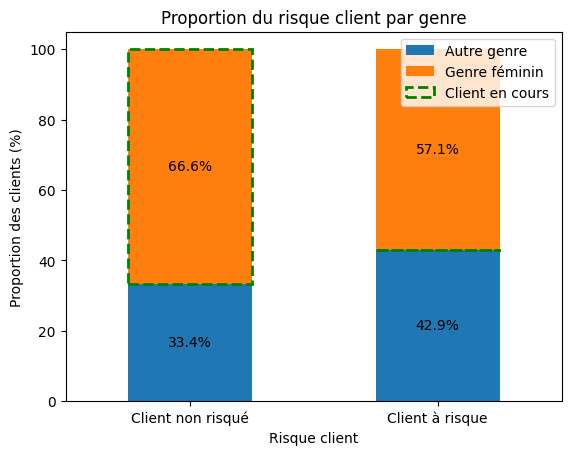

In [65]:
import copy

client_target = 0
client_code_gender_f = 1

feature_label = ['Autre genre','Genre féminin', 'Client en cours']
target_label = ['Client non risqué', 'Client à risque']

# Proportions des clients selon la target (colonne) et par genre (ligne)
proportions = data.groupby(['TARGET', feature])[feature].count() / data.groupby('TARGET')[feature].count()
proportions = proportions.unstack().transpose().to_numpy()*100

# Positionnement du client 
pos_client = np.zeros(2*2).reshape(2,2)
pos_client[client_code_gender_f, client_target] = 1
pos_client = pos_client * proportions  # On ne garde que la valeur Target et Genre correspondant au client

fig, ax = plt.subplots()
bottom = np.zeros(2)
pos_client_bottom = np.zeros(2)
for i, ligne in enumerate(proportions) :
    p = ax.bar([0.25, 0.75], ligne, width=0.25, bottom=bottom)
    if i == client_code_gender_f :
        pos_client_bottom = copy.deepcopy(bottom)  # On conserve la base pour pouvoir afficher la cellule du client après
    bottom += ligne
    ax.bar_label(p, label_type='center', fmt='%.1f%%')
#ax.bar([0.25, 0.75], pos_client[client_code_gender_f], width=0.25, bottom=pos_client_bottom,
#       color=None, linestyle='--', linewidth=3)
ax.bar([0.25, 0.75], pos_client[client_code_gender_f], width=0.25, bottom=pos_client_bottom,
       color='none', edgecolor='g', facecolor='none', linestyle='--', linewidth=2.0)
ax.set_xlabel('Risque client')
ax.set_ylabel('Proportion des clients (%)')
ax.set_title('Proportion du risque client par genre')
ax.set_xticks([0.25, 0.75], target_label)
ax.set_xlim([0, 1])
ax.legend(feature_label)
plt.show()

## Model graph var Quantitative (DAYS_BIRTH)

In [5]:
data.head()

,SK_ID_CURR,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,AMT_ALL_SUM_DEBT,AMT_ALL_SUM_OVERDUE,AMT_ALL_MAX_OVERDUE,CODE_GENDER_F,CODE_GENDER_M,CODE_GENDER_XNA,AMT_ALL_SUM_MEAN,RATIO_ALL_SUM_OVERDUE_TO_INCOME,RATIO_ALL_MAX_OVERDUE_TO_INCOME,RATIO_ALL_SUM_DEBT_TO_INCOME
0,100002,1.0,N,1,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,...,214462.080,0.000,5043.645,0,1,0,116012.285000,0.00000,0.298883,1.059072
1,100003,0.0,N,0,0,270000.0,1293502.5,35698.5,1129500.0,Family,...,3370.320,0.000,0.000,1,0,0,352853.357143,0.00000,0.000000,0.012483
2,100004,0.0,Y,1,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,...,4174.785,0.000,0.000,0,1,0,69714.600000,0.00000,0.000000,0.061849
3,100006,0.0,N,1,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,...,537202.035,0.000,0.000,1,0,0,343728.900000,0.00000,0.000000,3.979274
4,100007,0.0,N,1,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,...,237519.990,29857.365,22678.785,0,1,0,163726.071429,0.24574,2.239880,1.954897


<Axes: >

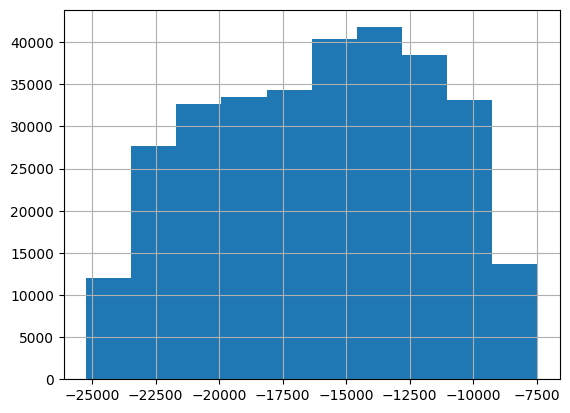

In [6]:
feature = 'DAYS_BIRTH'
data[feature].hist()

In [9]:
data_grouped = data.groupby('TARGET')[feature]
data_grouped.mean()

TARGET
0.0   -16138.176397
1.0   -14884.919513
Name: DAYS_BIRTH, dtype: float64

In [11]:
for name, group in data_grouped:
    print(name)
    print(group.head())

0.0
1   -16765
2   -19046
3   -19005
4   -19932
5   -16941
Name: DAYS_BIRTH, dtype: int64
1.0
0     -9461
26   -18724
40   -17482
42   -13384
81   -24794
Name: DAYS_BIRTH, dtype: int64


In [22]:
serie=[]
for name, group in data_grouped:
    serie.append(group.to_list())

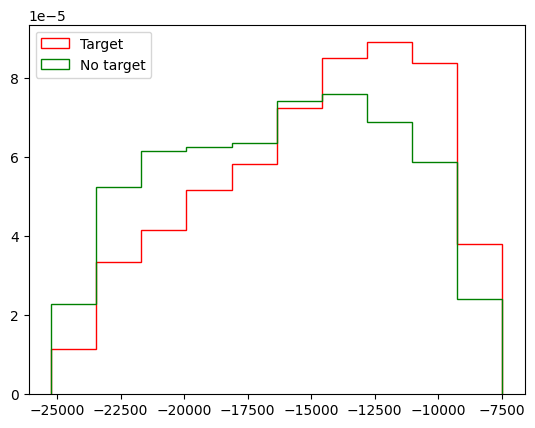

In [24]:
plt.hist(serie, density=True, label=['No target', 'Target'], color=['g', 'r'], histtype='step')
plt.legend()

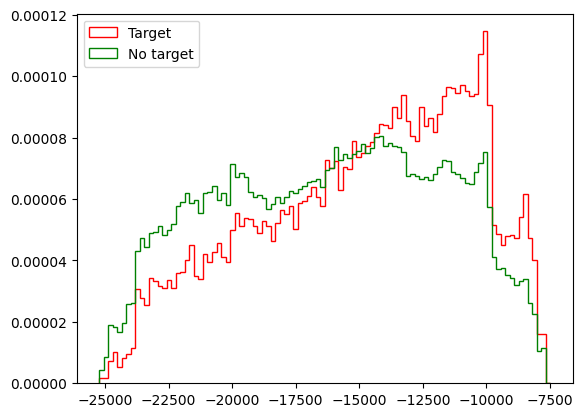

In [39]:
ax = plt.gca()
ax.hist(serie, bins=100, density=True, label=['No target', 'Target'], color=['g', 'r'], histtype='step')
plt.legend()

<Axes: ylabel='Density'>

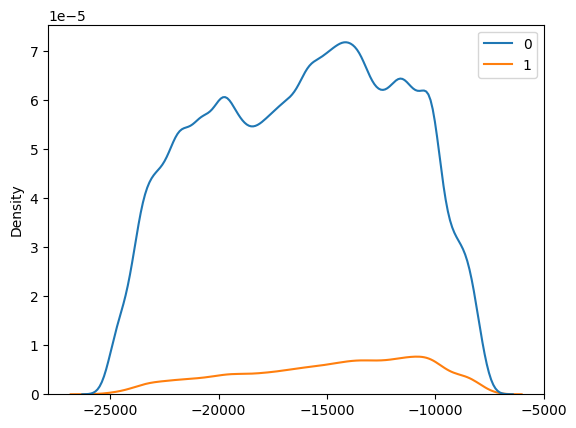

In [30]:
sns.kdeplot(serie, density=true)

<Axes: xlabel='DAYS_BIRTH', ylabel='Density'>

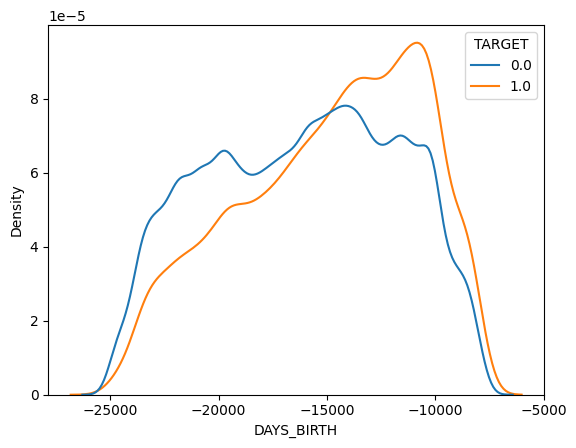

In [37]:
sns.kdeplot(data, x='DAYS_BIRTH', hue='TARGET', common_norm=False)

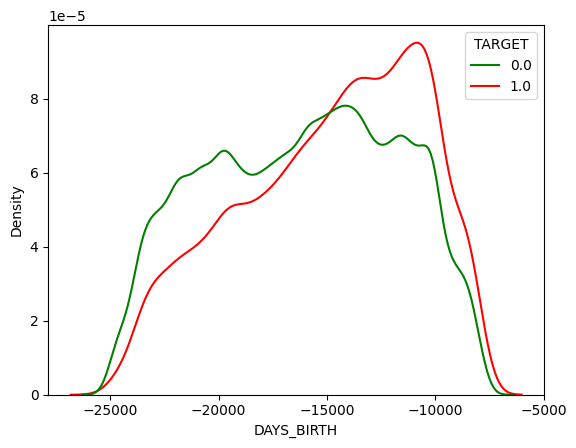

In [7]:
ax = sns.kdeplot(data, x='DAYS_BIRTH', hue='TARGET', common_norm=False, palette=['g', 'r'])

In [8]:
ax.get_legend_handles_labels()

([], [])

([], [])
['0.0', '1.0']


C:\Users\innov\AppData\Local\Temp\ipykernel_13180\2478199053.py:16: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend(handles, ['Zero', 'One'])


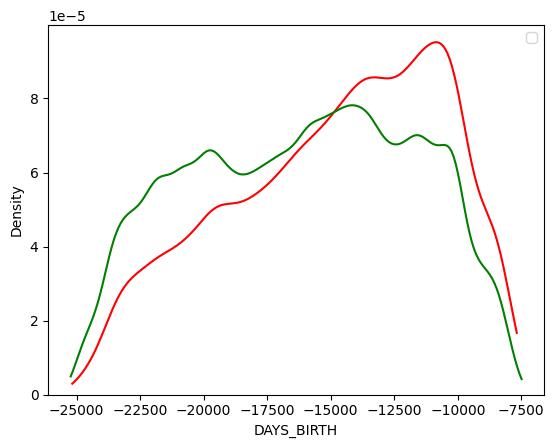

In [23]:
ax = sns.kdeplot(data, x='DAYS_BIRTH', hue='TARGET', common_norm=False, palette=['g', 'r'], cut=0)
# Get the legend object
legend = ax.get_legend()

# Check if a legend exists
if legend:
    # Extract handles and labels from the legend
    handles = ax.get_legend_handles_labels()
    labels = [text.get_text() for text in legend.texts]

    # Now you can work with the handles and labels
    print(handles)
    print(labels)
else:
    print("No legend found.")
ax.legend(handles, ['Zero', 'One'])

In [36]:
feature='AMT_ALL_SUM_MEAN'
xmax = data[feature].quantile(0.9)
xmin = data[feature].quantile(0.1)
print(xmin, xmax)


66600.594 563681.3359090909


<Axes: >

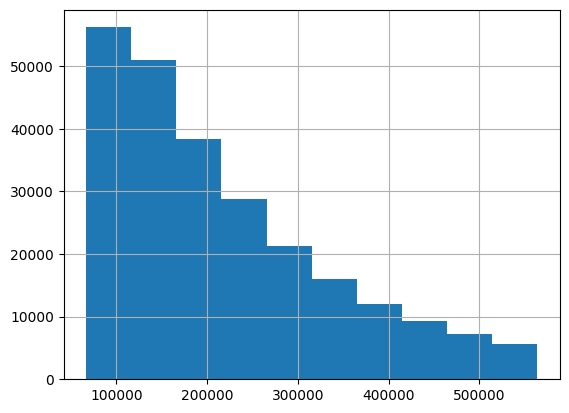

In [37]:
 data.loc[((data[feature] >= xmin) & (data[feature] <= xmax)), feature].hist()

# Graph bi-varié

In [48]:
domain_features

['DAYS_BIRTH',
 'CODE_GENDER_F',
 'FLAG_RISKED_ORGANIZATION_TYPE',
 'RATIO_INCOME_TO_FAM_MEMBERS',
 'FLAG_STABLE_INCOME_TYPE',
 'EXT_SOURCE_2',
 'AMT_ALL_SUM_MEAN',
 'RATIO_ALL_SUM_DEBT_TO_INCOME',
 'RATIO_ALL_SUM_OVERDUE_TO_INCOME',
 'RATIO_ALL_MAX_OVERDUE_TO_INCOME']

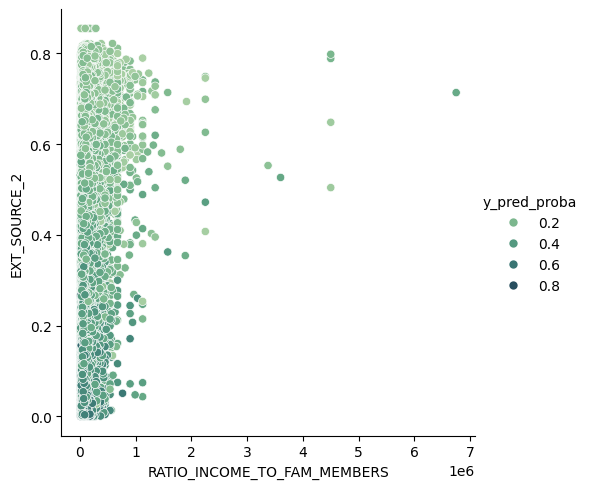

In [49]:
i=3
j=5  
sns.relplot(
    data=data,
    x=domain_features[i], y=domain_features[j],
    hue='y_pred_proba', palette="ch:r=-.5,l=.75"
)

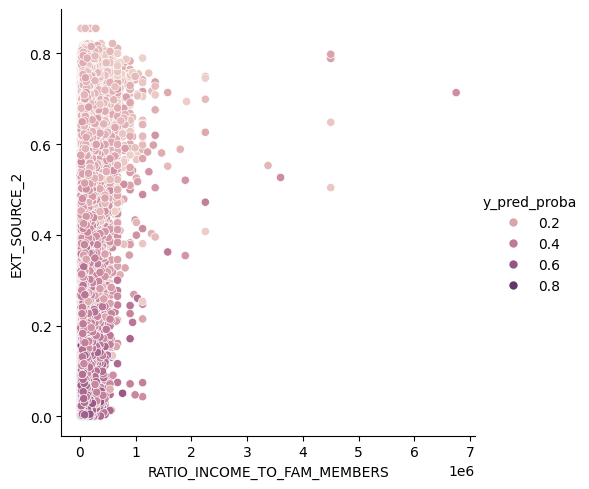

In [52]:
sns.relplot(data, x=domain_features[i], y=domain_features[j], hue='y_pred_proba')

In [53]:
import pandas as pd

# Exemple de données
data = {'Age': [25, 30, 22, 45, 38, 28, 50, 35, 42, 29]}
df = pd.DataFrame(data)

# Discrétisation en 3 intervalles de taille égale
df['Age_group'] = pd.cut(df['Age'], bins=3, labels=['Jeune', 'Adulte', 'Senior'])

# Discrétisation avec des intervalles personnalisés
bins = [0, 25, 40, 60, 100]
labels = ['Enfant', 'Jeune adulte', 'Adulte', 'Senior']
df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

print(df)

   Age     Age_group
0   25        Enfant
1   30  Jeune adulte
2   22        Enfant
3   45        Adulte
4   38  Jeune adulte
5   28  Jeune adulte
6   50        Adulte
7   35  Jeune adulte
8   42        Adulte
9   29  Jeune adulte


In [54]:
df['Age_group'] = pd.cut(df['Age'], bins=3)

In [55]:
df

,Age,Age_group
0,25,"(21.972, 31.333]"
1,30,"(21.972, 31.333]"
2,22,"(21.972, 31.333]"
3,45,"(40.667, 50.0]"
4,38,"(31.333, 40.667]"
5,28,"(21.972, 31.333]"
6,50,"(40.667, 50.0]"
7,35,"(31.333, 40.667]"
8,42,"(40.667, 50.0]"
9,29,"(21.972, 31.333]"
